In [ ]:
#MONTE CARLO PROJECTION

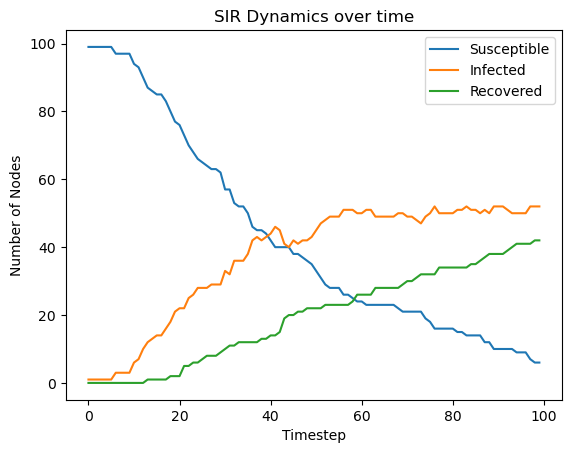

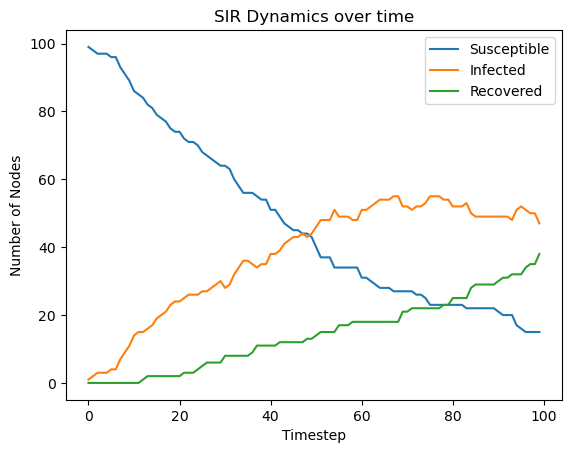

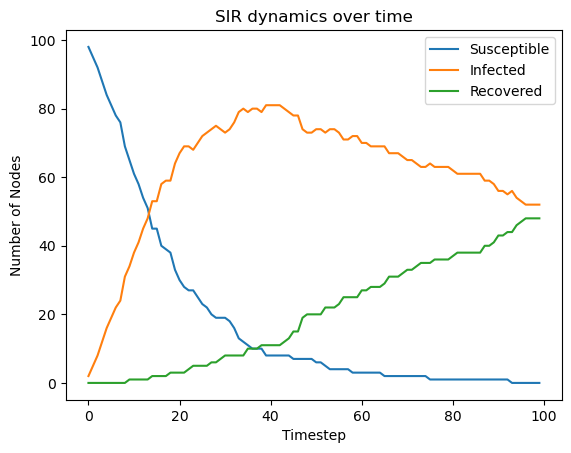

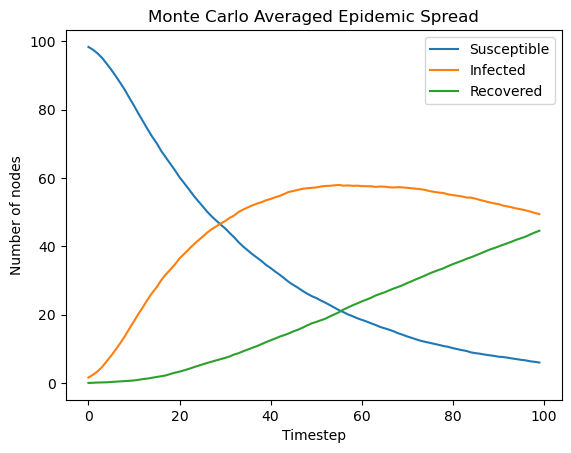

In [1]:
#MATT'S CODE:

import networkx as nx
import matplotlib.pyplot as plt
import random

# single random walk on ER graph
def er_graph(p_infection = 0.03,p_recovery=0.01):
    
    graph = nx.erdos_renyi_graph(100,0.2)
    timesteps = 100
    state = {}
    final_s = []
    final_i = []
    final_r = []
    
    
    #every node starts off as susceptible
    for node in graph.nodes():
        state[node] = 'S'
    # one becomes infected
    first_infect = random.choice(list(graph.nodes()))
    state[first_infect] = 'I'
    
    for i in range(timesteps):
        new_state = {}
        s_count = 0
        i_count = 0
        r_count = 0

        for node in graph.nodes():
            current_state = state[node]

            # creating list of possible infected neighbours 
            if current_state == 'S':
                i_neighbors = []
                for n in graph.neighbors(node):
                    if state[n] == 'I':
                        i_neighbors.append(n)
                        
                # if the node has infected neighbours, then possibility of infection       
                if i_neighbors and random.random() < p_infection:
                    new_state[node] = 'I'
                else:
                    new_state[node] = 'S'
                    
            # if the node is infected, possibility of recovery
            elif current_state == 'I':
                if random.random() < p_recovery:
                    new_state[node] = 'R'
                else: 
                    new_state[node] = 'I'
    
            else:
                new_state[node] = 'R'
                
        #update for next timestep, and keep count of number of S,I,R
        state = new_state
        for value in state.values():
            if value == 'S':
                s_count +=1
            elif value == 'I':
                i_count +=1
            else:
                r_count +=1
        final_s.append(s_count)
        final_i.append(i_count)
        final_r.append(r_count)
   
    return final_s, final_i, final_r;
    
# base example
s, i, r = er_graph(p_infection = 0.03, p_recovery = 0.01)
plt.plot(s, label='Susceptible')
plt.plot(i, label='Infected')
plt.plot(r, label='Recovered')
plt.xlabel('Timestep')
plt.ylabel('Number of Nodes')
plt.title('SIR Dynamics over time')
plt.legend()
plt.show()

# low infection example
s, i, r = er_graph(p_infection = 0.02, p_recovery = 0.01)
plt.plot(s, label='Susceptible')
plt.plot(i, label='Infected')
plt.plot(r, label='Recovered')
plt.xlabel('Timestep')
plt.ylabel('Number of Nodes')
plt.title('SIR Dynamics over time')
plt.legend()
plt.show()

# high infection example
s, i, r = er_graph(p_infection = 0.05, p_recovery = 0.01)
plt.plot(s, label='Susceptible')
plt.plot(i, label='Infected')
plt.plot(r, label='Recovered')
plt.xlabel('Timestep')
plt.ylabel('Number of Nodes')
plt.title('SIR dynamics over time')
plt.legend()
plt.show()

# monte carlo sims
simulations = 100
timesteps = 100
def monte_carlo():

    all_sums_s = []
    all_sums_i = []
    all_sums_r = []

    # run repeated simulations
    for run in range(simulations):
        s_list, i_list, r_list = er_graph()  
        all_sums_s.append(s_list)
        all_sums_i.append(i_list)
        all_sums_r.append(r_list)
    
    # per timestep averages
    avg_s = []
    avg_i = []
    avg_r = []
    
    for t in range(timesteps):
        avg_s.append(sum(run[t] for run in all_sums_s)/simulations)
        avg_i.append(sum(run[t] for run in all_sums_i)/simulations)
        avg_r.append(sum(run[t] for run in all_sums_r)/simulations)
    
    plt.plot(avg_s, label='Susceptible')
    plt.plot(avg_i, label='Infected')
    plt.plot(avg_r, label='Recovered')
    plt.xlabel('Timestep')
    plt.ylabel('Number of nodes')
    plt.title('Monte Carlo Averaged Epidemic Spread')
    plt.legend()
    plt.savefig('mc.pdf')
    plt.show()

monte_carlo()


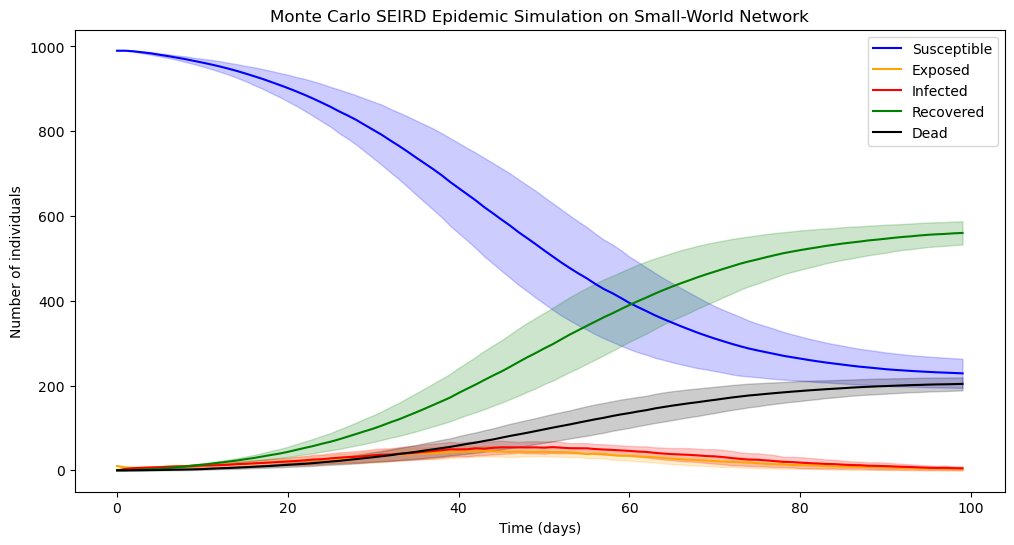

Network comparison:
Regular lattice:        C = 0.6667, L = 50.4505
Random graph:           C = 0.0099, L = 3.2835
Watts-Strogatz (β=0.3): C = 0.2410, L = 3.6250


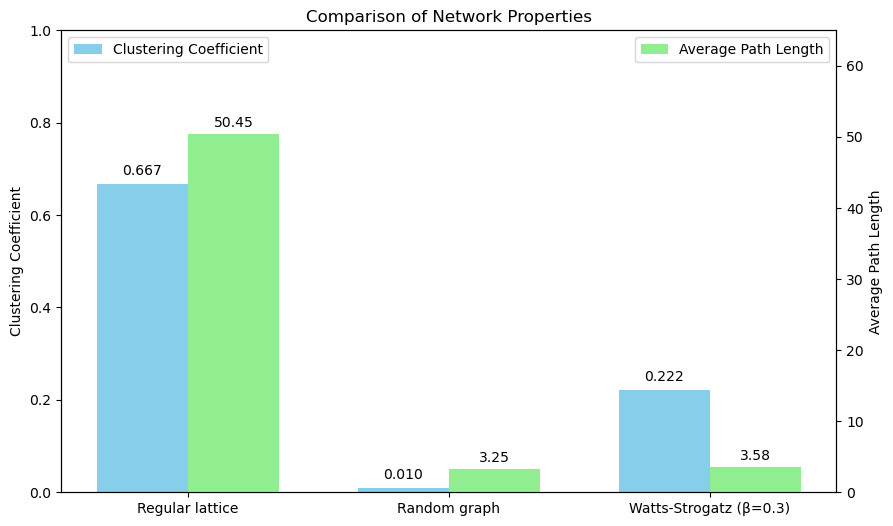

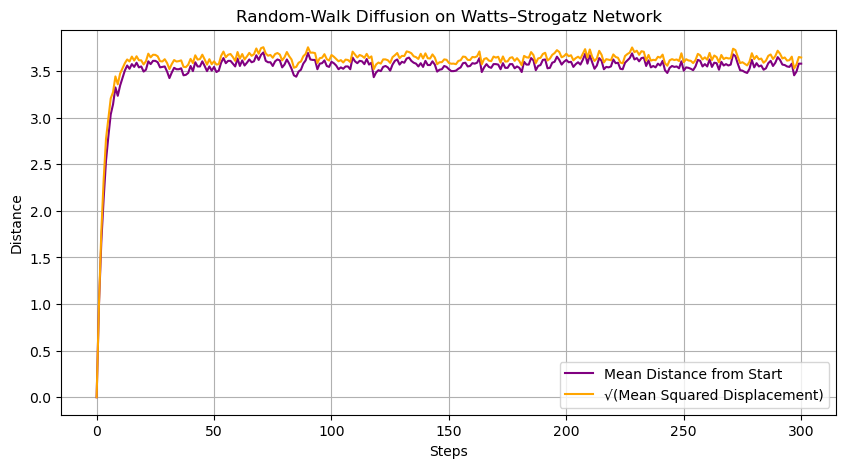

In [2]:
#CHELSEA'S CODE:

import networkx as nx
import random
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# PARAMETERS
N = 1000  # number of nodes
k = 10  # each node connected to k nearest neighbors
beta_rewire = 0.3  # Watts-Strogatz rewiring probability

time_steps = 100  # total simulation days
num_runs = 50  # number of Monte Carlo runs

# SEIRD disease parameters
base_beta = 0.05  # base infection probability per contact
sigma = 1/3  # E -> I probability (1/incubation period)
gamma = 1/5  # I -> R probability (1/infectious period)
mu_max = 0.5  # maximum mortality probability
max_days_I = 14  # days in I to reach maximum mortality

# Seasonal effects
seasonal_amplitude = 0.3
seasonal_period = 365  # one year

def beta_seasonal(base_beta, t, seasonal_period, seasonal_amplitude):
    # Sinusoidal seasonal variation
    return base_beta * (1 + seasonal_amplitude * math.sin(2 * math.pi * t / seasonal_period))

# Initial infection
initial_infected_fraction = 0.01

# FUNCTIONS
def initialize_network(N, k, beta_rewire):
    #Generate a Watts-Strogatz small-world network
    return nx.watts_strogatz_graph(N, k, beta_rewire)

def initialize_population(G, initial_infected_fraction):
    #Initialize all nodes as S, and infect a small fraction
    status = {node: 'S' for node in G.nodes()}
    status_timer = {node: 0 for node in G.nodes()}
    initial_infected = random.sample(list(G.nodes()), k=int(initial_infected_fraction * len(G.nodes())))
    for node in initial_infected:
        status[node] = 'E'
        status_timer[node] = 0
    return status, status_timer

def mortality_time_dep(t, mu_max, max_days_I):
    #Linear increase of mortality over time in infectious state
    return min(mu_max, mu_max * t / max_days_I)

def seird_step(G, status, status_timer, beta, sigma, gamma, mu_max, max_days_I):
    #One Monte Carlo step of SEIRD simulation
    new_status = status.copy()
    for node in G.nodes():
        if status[node] == 'I':
            # Try to infect neighbors
            for neighbor in G.neighbors(node):
                if status[neighbor] == 'S' and random.random() < beta:
                    new_status[neighbor] = 'E'
                    status_timer[neighbor] = 0
            # Time-dependent mortality
            t = status_timer[node]
            mu_t = mortality_time_dep(t, mu_max, max_days_I)
            r = random.random()
            if r < mu_t:
                new_status[node] = 'D'
                status_timer[node] = 0
            elif r < mu_t + gamma:
                new_status[node] = 'R'
                status_timer[node] = 0
            else:
                status_timer[node] += 1
        elif status[node] == 'E':
            # Exposed -> Infectious
            if random.random() < sigma:
                new_status[node] = 'I'
                status_timer[node] = 0
            else:
                status_timer[node] += 1
    return new_status, status_timer

# MONTE CARLO SIMULATION
G = initialize_network(N, k, beta_rewire)
history_runs = []

for run in range(num_runs):
    status, status_timer = initialize_population(G, initial_infected_fraction)
    run_history = []
   
    for t in range(time_steps):
        current_beta = beta_seasonal(base_beta, t, seasonal_period, seasonal_amplitude)
        run_history.append(list(status.values()))
        status, status_timer = seird_step(G, status, status_timer, current_beta, sigma, gamma, mu_max, max_days_I)
    history_runs.append(run_history)

# PROCESS RESULTS
# Convert to numpy array for stats
S_matrix = np.array([[step.count('S') for step in run] for run in history_runs])
E_matrix = np.array([[step.count('E') for step in run] for run in history_runs])
I_matrix = np.array([[step.count('I') for step in run] for run in history_runs])
R_matrix = np.array([[step.count('R') for step in run] for run in history_runs])
D_matrix = np.array([[step.count('D') for step in run] for run in history_runs])

# Compute mean and std
S_mean, S_std = S_matrix.mean(axis=0), S_matrix.std(axis=0)
E_mean, E_std = E_matrix.mean(axis=0), E_matrix.std(axis=0)
I_mean, I_std = I_matrix.mean(axis=0), I_matrix.std(axis=0)
R_mean, R_std = R_matrix.mean(axis=0), R_matrix.std(axis=0)
D_mean, D_std = D_matrix.mean(axis=0), D_matrix.std(axis=0)

# PLOT RESULTS
days = range(time_steps)
plt.figure(figsize=(12,6))
plt.plot(days, S_mean, label='Susceptible', color='blue')
plt.fill_between(days, S_mean - S_std, S_mean + S_std, color='blue', alpha=0.2)
plt.plot(days, E_mean, label='Exposed', color='orange')
plt.fill_between(days, E_mean - E_std, E_mean + E_std, color='orange', alpha=0.2)
plt.plot(days, I_mean, label='Infected', color='red')
plt.fill_between(days, I_mean - I_std, I_mean + I_std, color='red', alpha=0.2)
plt.plot(days, R_mean, label='Recovered', color='green')
plt.fill_between(days, R_mean - R_std, R_mean + R_std, color='green', alpha=0.2)
plt.plot(days, D_mean, label='Dead', color='black')
plt.fill_between(days, D_mean - D_std, D_mean + D_std, color='black', alpha=0.2)
plt.xlabel('Time (days)')
plt.ylabel('Number of individuals')
plt.title('Monte Carlo SEIRD Epidemic Simulation on Small-World Network')
plt.legend()
plt.show()

import networkx as nx

# Parameter
N = 1000      # number of nodes
k = 10        # k nearest neighbors
beta_ws = 0.3 # rewiring probability 

# Regular lattice
G_lattice = nx.watts_strogatz_graph(N, k, 0)
C_lattice = nx.average_clustering(G_lattice)
L_lattice = nx.average_shortest_path_length(G_lattice)

# Random graph
p = k / (N-1)  # probability for each edge to exist
G_random = nx.erdos_renyi_graph(N, p)
C_random = nx.average_clustering(G_random)
L_random = nx.average_shortest_path_length(G_random)

# Watts-Strogatz
G_ws = nx.watts_strogatz_graph(N, k, beta_ws)
C_ws = nx.average_clustering(G_ws)
L_ws = nx.average_shortest_path_length(G_ws)

# Resukts
print("Network comparison:")
print(f"Regular lattice:        C = {C_lattice:.4f}, L = {L_lattice:.4f}")
print(f"Random graph:           C = {C_random:.4f}, L = {L_random:.4f}")
print(f"Watts-Strogatz (β={beta_ws}): C = {C_ws:.4f}, L = {L_ws:.4f}")

import matplotlib.pyplot as plt
import numpy as np

networks = ['Regular lattice', 'Random graph', 'Watts-Strogatz (β=0.3)']
clustering = [0.6667, 0.0096, 0.2215]
path_length = [50.4505, 3.2486, 3.5843]

x = np.arange(len(networks))  # label locations
width = 0.35  # bar width

fig, ax1 = plt.subplots(figsize=(10,6))

# Plot clustering coefficient bars
bars1 = ax1.bar(x - width/2, clustering, width, label='Clustering Coefficient', color='skyblue')
ax1.set_ylabel('Clustering Coefficient')
ax1.set_ylim(0, 1)
ax1.set_xticks(x)
ax1.set_xticklabels(networks)
ax1.set_title('Comparison of Network Properties')
ax1.legend(loc='upper left')

# Plot average path length on secondary y-axis
ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, path_length, width, label='Average Path Length', color='lightgreen')
ax2.set_ylabel('Average Path Length')
ax2.set_ylim(0, 65)
ax2.legend(loc='upper right')

# Annotate
for i in range(len(networks)):
    ax1.text(i - width/2, clustering[i]+0.02, f'{clustering[i]:.3f}', ha='center')
    ax2.text(i + width/2, path_length[i]+1, f'{path_length[i]:.2f}', ha='center')

plt.show()

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import random

# Parameters
walk_steps = 300
num_walkers = 200

# WS graph from before
G_rw = nx.watts_strogatz_graph(N, k, beta_rewire)

# Shortest paths (for distance)
shortest_paths = dict(nx.all_pairs_shortest_path_length(G_rw))

def random_walk(G, start, steps):
    """Runs a simple unbiased random walk."""
    pos = start
    path = [pos]
    for _ in range(steps):
        pos = random.choice(list(G.neighbors(pos)))
        path.append(pos)
    return path

all_distances = []
all_visited_counts = []

for w in range(num_walkers):
    start = random.choice(list(G_rw.nodes()))
    path = random_walk(G_rw, start, walk_steps)

    # Distance from start over time
    distances = [shortest_paths[start][node] for node in path]
    all_distances.append(distances)

# Convert to arrays
all_distances = np.array(all_distances)

mean_distance = all_distances.mean(axis=0)
mean_msd = (all_distances ** 2).mean(axis=0)

plt.figure(figsize=(10,5))
plt.plot(mean_distance, label="Mean Distance from Start", color='purple')
plt.plot(np.sqrt(mean_msd), label="√(Mean Squared Displacement)", color='orange')
plt.xlabel("Steps")
plt.ylabel("Distance")
plt.title("Random-Walk Diffusion on Watts–Strogatz Network")
plt.grid(True)
plt.legend()
plt.show()


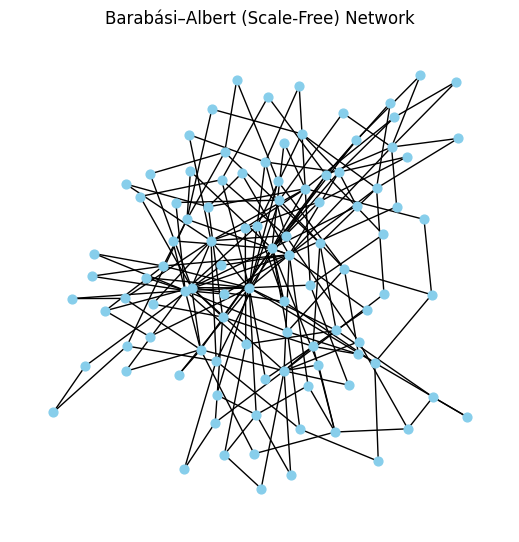

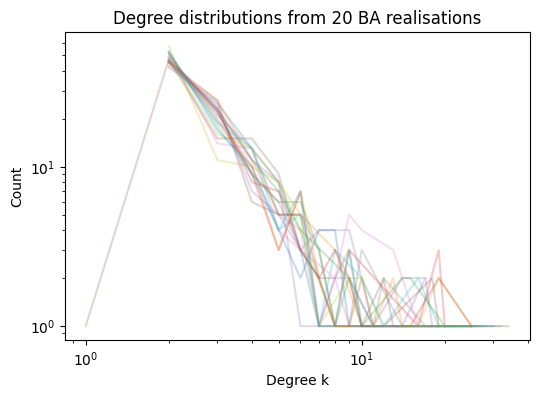

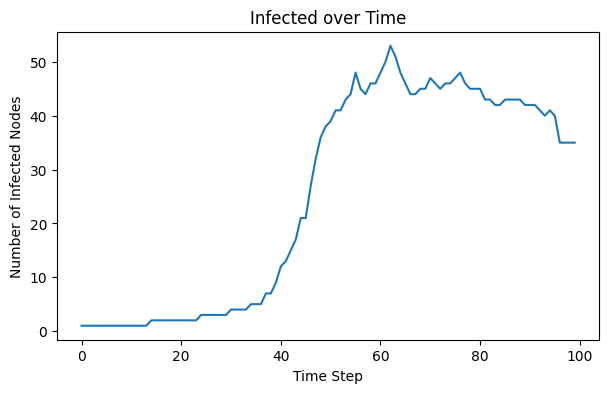

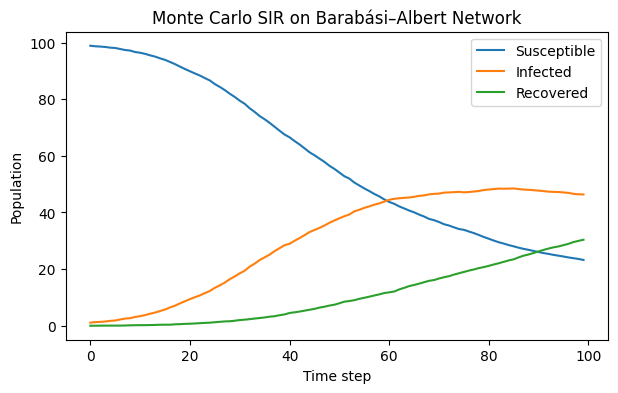

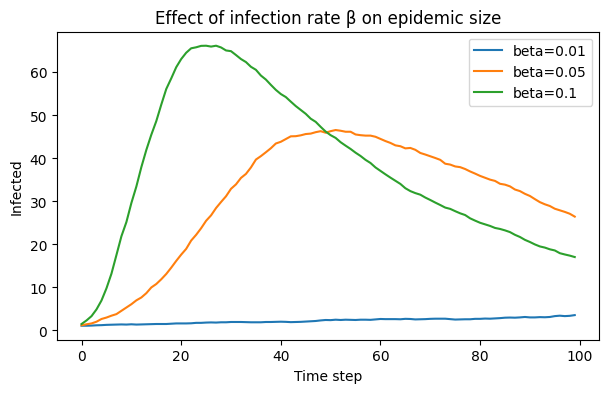

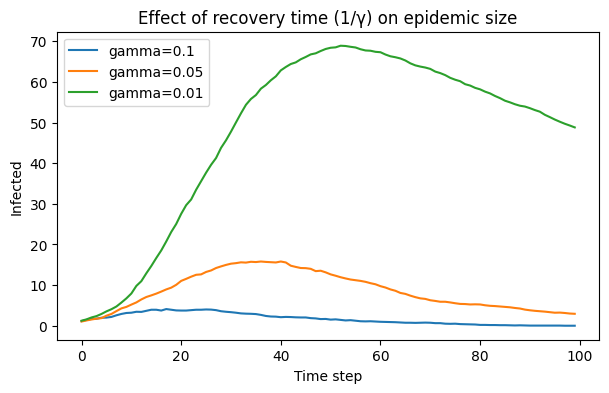

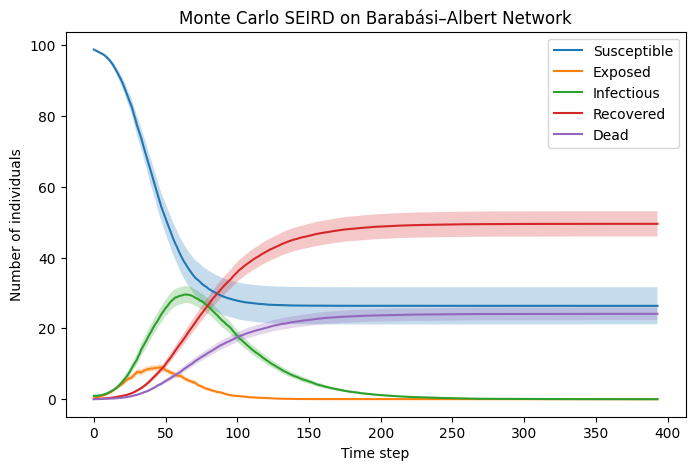

In [1]:
#KEVIN'S CODE

import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

N = 100          
m = 2           

G = nx.barabasi_albert_graph(N, m)

plt.figure(figsize=(5,5))
nx.draw(G, node_size=40, node_color="skyblue")
plt.title("Barabási–Albert (Scale-Free) Network")
plt.show()

plt.figure(figsize=(6,4))
for _ in range(20):
    G = nx.barabasi_albert_graph(N, m)
    degs = [d for _, d in G.degree()]
    ks, counts = np.unique(degs, return_counts=True)
    plt.loglog(ks, counts, alpha=0.25)
plt.title('Degree distributions from 20 BA realisations')
plt.xlabel('Degree k')
plt.ylabel('Count')
plt.show()

import random

def sir_simulation(G, beta=0.05, gamma=0.02, steps=100):
    states = {node: 0 for node in G.nodes()}
    patient_zero = random.choice(list(G.nodes()))
    states[patient_zero] = 1

    history = []

    for t in range(steps):
        new_states = states.copy()
        for node in G.nodes():
            if states[node] == 1: 
                for neighbor in G.neighbors(node):
                    if states[neighbor] == 0 and random.random() < beta:
                        new_states[neighbor] = 1
                if random.random() < gamma:
                    new_states[node] = 2
        states = new_states
        infected_count = sum(1 for s in states.values() if s == 1)
        history.append(infected_count)
    return history

history = sir_simulation(G, beta=0.05, gamma=0.02, steps=100)

plt.figure(figsize=(7,4))
plt.plot(history)
plt.title("Infected over Time")
plt.xlabel("Time Step")
plt.ylabel("Number of Infected Nodes")
plt.show()

def sir_simulation2(G, beta, gamma, steps):
    states = {node: 0 for node in G.nodes()} 
    patient_zero = random.choice(list(G.nodes()))
    states[patient_zero] = 1

    S, I, R = [], [], []

    for t in range(steps):
        new_states = states.copy()

        for node in G.nodes():
            if states[node] == 1:
                for neighbor in G.neighbors(node):
                    if states[neighbor] == 0 and random.random() < beta:
                        new_states[neighbor] = 1
                if random.random() < gamma:
                    new_states[node] = 2

        states = new_states

        S.append(sum(1 for s in states.values() if s == 0))
        I.append(sum(1 for s in states.values() if s == 1))
        R.append(sum(1 for s in states.values() if s == 2))

    return np.array(S), np.array(I), np.array(R)


def monte_carlo_sir(G, beta, gamma, steps=100, runs=50):
    all_S, all_I, all_R = [], [], []

    for _ in range(runs):
        S, I, R = sir_simulation2(G, beta, gamma, steps)
        all_S.append(S)
        all_I.append(I)
        all_R.append(R)

    mean_S = np.mean(all_S, axis=0)
    mean_I = np.mean(all_I, axis=0)
    mean_R = np.mean(all_R, axis=0)

    return mean_S, mean_I, mean_R


steps = 100
beta = 0.03
gamma = 0.01

mean_S, mean_I, mean_R = monte_carlo_sir(G, beta, gamma, steps, runs=50)

plt.figure(figsize=(7,4))
plt.plot(mean_S, label="Susceptible")
plt.plot(mean_I, label="Infected")
plt.plot(mean_R, label="Recovered")
plt.xlabel("Time step")
plt.ylabel("Population")
plt.title("Monte Carlo SIR on Barabási–Albert Network")
plt.legend()
plt.show()

betas = [0.01, 0.05, 0.1]

plt.figure(figsize=(7,4))

for b in betas:
    _, I, _ = monte_carlo_sir(G, beta=b, gamma=0.02, runs=30)
    plt.plot(I, label=f"beta={b}")

plt.title("Effect of infection rate β on epidemic size")
plt.xlabel("Time step")
plt.ylabel("Infected")
plt.legend()
plt.show()

gammas = [0.1, 0.05, 0.01] 

plt.figure(figsize=(7,4))

for g in gammas:
    _, I, _ = monte_carlo_sir(G, beta=0.05, gamma=g, runs=30)
    plt.plot(I, label=f"gamma={g}")

plt.xlabel("Time step")
plt.ylabel("Infected")
plt.title("Effect of recovery time (1/γ) on epidemic size")
plt.legend()
plt.show()

def run_seird(G, beta=0.06, sigma=0.15, gamma=0.02, mu=0.01, max_steps=500, initial_infected=None):
    states = {n: 0 for n in G.nodes()}

    if initial_infected is None:
        seed = random.choice(list(G.nodes()))
    else:
        seed = initial_infected

    states[seed] = 2  

    S_hist, E_hist, I_hist, R_hist, D_hist = [], [], [], [], []

    for t in range(max_steps):
        new_states = states.copy()

        for u, state in states.items():

            if state == 2:
                for v in G.neighbors(u):
                    if states[v] == 0 and random.random() < beta:
                        new_states[v] = 1

                if random.random() < gamma:
                    new_states[u] = 3
                elif random.random() < mu:
                    new_states[u] = 4

            elif state == 1: 
                if random.random() < sigma:
                    new_states[u] = 2

        states = new_states

        S_hist.append(sum(s == 0 for s in states.values()))
        E_hist.append(sum(s == 1 for s in states.values()))
        I_hist.append(sum(s == 2 for s in states.values()))
        R_hist.append(sum(s == 3 for s in states.values()))
        D_hist.append(sum(s == 4 for s in states.values()))

        if I_hist[-1] == 0 and E_hist[-1] == 0:
            break

    return np.array(S_hist), np.array(E_hist), np.array(I_hist), np.array(R_hist), np.array(D_hist)

def monte_carlo_seird(G, beta, sigma, gamma, mu, runs=200):
    S_trajs = []
    E_trajs = []
    I_trajs = []
    R_trajs = []
    D_trajs = []

    for _ in range(runs):
        S, E, I, R, D = run_seird(G, beta, sigma, gamma, mu)

        S_trajs.append(S)
        E_trajs.append(E)
        I_trajs.append(I)
        R_trajs.append(R)
        D_trajs.append(D)

    return {
        "S_trajs": S_trajs,
        "E_trajs": E_trajs,
        "I_trajs": I_trajs,
        "R_trajs": R_trajs,
        "D_trajs": D_trajs
    }

res_seird = monte_carlo_seird(G,beta=0.06,sigma=0.15,gamma=0.02,mu=0.01,runs=200)

from scipy.stats import t as student_t

def pad_trajs(trajs):
    L = max(len(tr) for tr in trajs)
    return np.array([np.pad(tr, (0, L - len(tr)), mode='edge') for tr in trajs])

S_arr = pad_trajs(res_seird['S_trajs'])
E_arr = pad_trajs(res_seird['E_trajs'])
I_arr = pad_trajs(res_seird['I_trajs'])
R_arr = pad_trajs(res_seird['R_trajs'])
D_arr = pad_trajs(res_seird['D_trajs'])

time = np.arange(S_arr.shape[1])

def mean_ci(arr, alpha=0.05):
    mean = arr.mean(axis=0)
    sd   = arr.std(axis=0, ddof=1)
    se   = sd / np.sqrt(arr.shape[0])
    tval = student_t.ppf(1 - alpha/2, arr.shape[0] - 1)
    lower = mean - tval * se
    upper = mean + tval * se
    return mean, lower, upper

mS, lS, uS = mean_ci(S_arr)
mE, lE, uE = mean_ci(E_arr)
mI, lI, uI = mean_ci(I_arr)
mR, lR, uR = mean_ci(R_arr)
mD, lD, uD = mean_ci(D_arr)

plt.figure(figsize=(8,5))

plt.plot(time, mS, label="Susceptible")
plt.fill_between(time, lS, uS, alpha=0.25)

plt.plot(time, mE, label="Exposed")
plt.fill_between(time, lE, uE, alpha=0.25)

plt.plot(time, mI, label="Infectious")
plt.fill_between(time, lI, uI, alpha=0.25)

plt.plot(time, mR, label="Recovered")
plt.fill_between(time, lR, uR, alpha=0.25)

plt.plot(time, mD, label="Dead")
plt.fill_between(time, lD, uD, alpha=0.25)

plt.xlabel("Time step")
plt.ylabel("Number of individuals")
plt.title("Monte Carlo SEIRD on Barabási–Albert Network")
plt.legend()
plt.show()
